# Entrega 2 · Pré-processamento e pipelines

**CIN0144 — Aprendizado de Máquina e Ciência de Dados · Grupo 11**

Ana Laura, Ana Raquel e Laura Virginia

Este notebook contém apenas o experimento da Entrega 2. A análise exploratória está no
notebook da Entrega 1 e não é repetida aqui.

O experimento é um pipeline parametrizável de cinco etapas, avaliado em todas as 144
combinações possíveis das opções escolhidas, sempre com o mesmo classificador: um kNN de
sete vizinhos, fixado pelo enunciado para que toda diferença venha do pré-processamento.

A ordem das etapas dentro de cada fold é

    ausentes → encoding → normalização → redução → balanceamento → kNN

e as razões de cada posição estão na seção 4 do relatório.

In [1]:
import platform
import sys
import time
import warnings
from pathlib import Path

import imblearn
import numpy as np
import pandas as pd
import sklearn
from sklearn.metrics import get_scorer

# o caminho e relativo ao repositorio, para a saida nao expor a maquina de ninguem
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

from e2 import analise, base, espaco
from e2.metricas import SCORING

warnings.filterwarnings("ignore")
RESULTADOS = RAIZ / "reports" / "e2"

print("ambiente desta execucao")
print("  python %s | scikit-learn %s | imbalanced-learn %s"
      % (platform.python_version(), sklearn.__version__, imblearn.__version__))
print("  pandas %s | numpy %s | sistema %s"
      % (pd.__version__, np.__version__, platform.platform(terse=True)))
print("protocolo")
print("  semente %d | vizinhos %d | ordem %s"
      % (base.SEMENTE, espaco.K_VIZINHOS, " -> ".join(espaco.ETAPAS)))

ambiente desta execucao
  python 3.13.16 | scikit-learn 1.9.1 | imbalanced-learn 0.14.2
  pandas 3.0.5 | numpy 2.5.3 | sistema Linux-6.18.44-fc-v80-x86_64-with-glibc2.39
protocolo
  semente 42 | vizinhos 7 | ordem ausentes -> encoding -> normalizacao -> reducao -> balanceamento


## 1 · A base e a partição

O alvo é público acima do percentil 75 dos filmes brasileiros do ano anterior. Os cinco folds
são gerados uma única vez e reaproveitados por todas as combinações, de modo que duas linhas da
tabela de resultados diferem apenas pelo pré-processamento.

In [2]:
X, y, ano = base.carregar_xy()
pares = base.folds()

print("filmes com alvo: %d" % len(y))
print("atributos: %d" % X.shape[1])
print("prevalencia de sucesso: %.3f" % y.mean())
print("folds: %d" % len(pares))
print("prevalencia por fold: %s" % ", ".join("%.3f" % y.iloc[t].mean() for _, t in pares))
print("anos: %d a %d" % (ano.min(), ano.max()))

filmes com alvo: 2590
atributos: 18
prevalencia de sucesso: 0.253
folds: 5
prevalencia por fold: 0.251, 0.253, 0.253, 0.253, 0.253
anos: 1996 a 2024


O histórico de público de direção, distribuidora e produtora é o único ponto em que informação
de um filme passa por outro, e por isso tem verificação própria: o teste multiplica por mil o
público de um ano e confere que nenhum histórico daquele ano ou anterior se altera.

In [3]:
print("o historico so olha para tras:", base.checar_nao_vazamento())

o historico so olha para tras: True


## 2 · O espaço de pipelines

Cada etapa é um módulo que declara as suas opções. O espaço é o produto delas, e a
configuração sem nenhuma transformação opcional existe na grade como referência de todas as
comparações.

In [4]:
for etapa in espaco.ETAPAS:
    opcoes = list(espaco.opcoes(etapa))
    print("%-14s %d  %s" % (etapa, len(opcoes), ", ".join(opcoes)))

combinacoes = espaco.combinacoes()
print("\ncombinacoes: %d" % len(combinacoes))
print("baseline: %s" % espaco.codigo(espaco.BASELINE))
print("baselines na grade: %d" % sum(espaco.eh_baseline(c) for c in combinacoes))

ausentes       2  mediana_moda, mediana_indicadora
encoding       2  onehot, alvo
normalizacao   4  sem, padrao, minmax, robusto
reducao        3  sem, pca, kbest
balanceamento  3  sem, subamostragem, smote

combinacoes: 144
baseline: mediana_moda|onehot|sem|sem|sem
baselines na grade: 1


Cada opção tem uma justificativa amarrada a uma característica concreta dos dados medida na
Entrega 1. Elas estão nos módulos das etapas e são o conteúdo da seção 3 do relatório.

In [5]:
import importlib

for etapa in espaco.ETAPAS:
    modulo = importlib.import_module("e2.etapas.%s" % etapa)
    print("### %s" % etapa)
    for opcao, texto in modulo.JUSTIFICATIVA.items():
        print("  %-20s %s" % (opcao, texto.split(".")[0] + "."))

### ausentes
  mediana_moda         A imputação mais elementar.
  mediana_indicadora   A E1 separou a ausência em quatro naturezas e mostrou que ausência pode ser informação, como em max_salas e em coproducao.
### encoding
  onehot               A técnica padrão para nominais.
  alvo                 Distribuidora tem 455 categorias, 278 com um único filme.
### normalizacao
  sem                  Referência: mede se as escalas cruas já servem ao kNN, em que ano vai de 1996 a 2024 e as binárias de 0 a 1.
  padrao               Põe todas as colunas na mesma escala de desvio.
  minmax               Leva tudo a [0, 1] sem mexer nas dummies, que continuam 0 e 1.
  robusto              Centra na mediana e divide pelo intervalo interquartil, pensado para as contagens de filmes anteriores, com assimetria de 2,0 a 3,8.
### reducao
  sem                  Testa a H13 da Entrega 1, não aplicar PCA, agora com um modelo sensível à dimensão; a H13 foi medida com floresta, que não é.
  pca             

O pipeline de uma combinação, montado. O objeto é do `imbalanced-learn` porque é o único que
aceita um reamostrador no meio da sequência e o aciona apenas no ajuste, de modo que o fold de
teste nunca é reamostrado.

In [6]:
exemplo = [c for c in combinacoes if espaco.codigo(c) == "mediana_moda|alvo|padrao|pca|subamostragem"][0]
espaco.construir_pipeline(exemplo)

,steps,"[('ausentes', ...), ('encoding', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_

## 3 · Execução das 144 combinações

Cada combinação é ajustada e medida nos cinco folds. Todo o pré-processamento vive dentro do
pipeline, então medianas de imputação, categorias do encoding, parâmetros de escala e eixos do
PCA são estimados no treino de cada fold e aplicados ao teste.

Combinação que lançasse exceção entraria na tabela com a mensagem de erro, em vez de derrubar a
grade. Nenhuma lançou.

In [7]:
def avaliar(config):
    """Ajusta e mede a combinacao em cada fold. Devolve uma linha por fold."""
    linhas = []
    for fold, (treino, teste) in enumerate(pares):
        pipe = espaco.construir_pipeline(config)
        inicio = time.perf_counter()
        pipe.fit(X.iloc[treino], y.iloc[treino])
        ajuste = time.perf_counter() - inicio

        inicio = time.perf_counter()
        linha = {n: get_scorer(s)(pipe, X.iloc[teste], y.iloc[teste]) for n, s in SCORING.items()}
        linha.update(id=config["id"], fold=fold, tempo_ajuste_s=ajuste,
                     tempo_predicao_s=time.perf_counter() - inicio)
        linhas.append(linha)
    return linhas


inicio_da_grade = time.perf_counter()
por_fold = []
for config in combinacoes:
    por_fold += avaliar(config)
    if config["id"] % 24 == 0:
        print("%3d de %d combinacoes" % (config["id"], len(combinacoes)))

por_fold = pd.DataFrame(por_fold)
print("\n%d linhas, %.1f minutos" % (len(por_fold), (time.perf_counter() - inicio_da_grade) / 60))

 24 de 144 combinacoes


 48 de 144 combinacoes


 72 de 144 combinacoes


 96 de 144 combinacoes


120 de 144 combinacoes


144 de 144 combinacoes

720 linhas, 4.0 minutos


In [8]:
# media e desvio amostral entre os cinco folds, por combinacao
agregado = por_fold.groupby("id")[list(SCORING)].agg(["mean", "std"])
agregado.columns = ["%s_%s" % (m, "media" if e == "mean" else "dp") for m, e in agregado.columns]

meta = pd.DataFrame(combinacoes).assign(
    codigo=[espaco.codigo(c) for c in combinacoes],
    eh_baseline=[int(espaco.eh_baseline(c)) for c in combinacoes])
tempo = por_fold.groupby("id").apply(
    lambda d: (d["tempo_ajuste_s"] + d["tempo_predicao_s"]).sum(), include_groups=False)

resultados = meta.merge(agregado, on="id").assign(tempo_total_s=tempo.values, erro="")
resultados[["id", "codigo", "roc_auc_media", "roc_auc_dp", "f1_media", "tempo_total_s"]].head(8)

,id,codigo,roc_auc_media,roc_auc_dp,f1_media,tempo_total_s
0,1,mediana_moda|onehot|sem|sem|sem,0.827166,0.013975,0.542969,0.780717
1,2,mediana_moda|onehot|sem|sem|subamostragem,0.807185,0.029372,0.587800,0.783282
2,3,mediana_moda|onehot|sem|sem|smote,0.818532,0.013322,0.612369,0.847092
3,4,mediana_moda|onehot|sem|pca|sem,0.750785,0.012093,0.464203,0.708004
4,5,mediana_moda|onehot|sem|pca|subamostragem,0.731674,0.015095,0.516016,0.832320
5,6,mediana_moda|onehot|sem|pca|smote,0.762144,0.017209,0.537569,0.823979
6,7,mediana_moda|onehot|sem|kbest|sem,0.813166,0.006862,0.596652,3.667707
7,8,mediana_moda|onehot|sem|kbest|subamostragem,0.811617,0.015878,0.618747,3.327526


A grade também é executada por `python src/executar_e2.py`, que grava os arquivos em
`reports/e2/`. A célula abaixo confere que o que este notebook acabou de calcular é igual ao
que está gravado no repositório. Se a diferença não for nula, é porque o notebook rodou num
ambiente diferente do da execução de referência, e o anexo do relatório explica o efeito.

In [9]:
gravado = pd.read_csv(RESULTADOS / "resultados.csv").sort_values("id").reset_index(drop=True)
agora = resultados.sort_values("id").reset_index(drop=True)
colunas = [m + s for m in SCORING for s in ("_media", "_dp")]

print("combinacoes gravadas:", len(gravado), "| recalculadas:", len(agora))
print("mesma ordem de codigos:", (gravado["codigo"] == agora["codigo"]).all())
print("maior diferenca absoluta nas metricas: %.2e" % (gravado[colunas] - agora[colunas]).abs().max().max())

combinacoes gravadas: 144 | recalculadas: 144
mesma ordem de codigos: True
maior diferenca absoluta nas metricas: 2.22e-16


## 4 · Leitura dos resultados

A regra de empate do enunciado tem uma implementação só, em `src/e2/analise.py`, e é usada por
todas as leituras abaixo: duas combinações empatam numa métrica quando a diferença entre as
médias é menor que o maior dos dois desvios entre folds.

In [10]:
ranking = analise.ranking(gravado)
linha_base = gravado[gravado["eh_baseline"] == 1].iloc[0]

print("melhor:   %s  %.3f +- %.3f" % (ranking.iloc[0]["codigo"],
                                      ranking.iloc[0]["roc_auc_media"], ranking.iloc[0]["roc_auc_dp"]))
print("baseline: %s  %.3f +- %.3f  posicao %d"
      % (linha_base["codigo"], linha_base["roc_auc_media"], linha_base["roc_auc_dp"],
         int(ranking[ranking["codigo"] == linha_base["codigo"]]["posicao"].iloc[0])))
print("pior:     %s  %.3f +- %.3f" % (ranking.iloc[-1]["codigo"],
                                      ranking.iloc[-1]["roc_auc_media"], ranking.iloc[-1]["roc_auc_dp"]))
print("\nempatam com a melhor:   %d de 144" % ranking["empata_com_a_melhor"].sum())
print("empatam com o baseline: %d de 144" % ranking["empata_com_o_baseline"].sum())
ranking.head(10)

melhor:   mediana_moda|alvo|padrao|pca|subamostragem  0.853 +- 0.016
baseline: mediana_moda|onehot|sem|sem|sem  0.827 +- 0.014  posicao 61
pior:     mediana_indicadora|onehot|sem|pca|subamostragem  0.731 +- 0.015

empatam com a melhor:   22 de 144
empatam com o baseline: 105 de 144


,posicao,id,codigo,roc_auc_media,roc_auc_dp,empata_com_a_melhor,empata_com_o_baseline
0,1,50,mediana_moda|alvo|padrao|pca|subamostragem,0.852847,0.015924,True,False
1,2,58,mediana_moda|alvo|minmax|pca|sem,0.850145,0.010431,True,False
2,3,47,mediana_moda|alvo|padrao|sem|subamostragem,0.848021,0.017353,True,False
3,4,55,mediana_moda|alvo|minmax|sem|sem,0.847528,0.014142,True,False
4,5,122,mediana_indicadora|alvo|padrao|pca|subamostragem,0.847062,0.015979,True,False
5,6,56,mediana_moda|alvo|minmax|sem|subamostragem,0.846047,0.013334,True,False
6,7,119,mediana_indicadora|alvo|padrao|sem|subamostragem,0.845614,0.016054,True,False
7,8,59,mediana_moda|alvo|minmax|pca|subamostragem,0.843324,0.016981,True,True
8,9,134,mediana_indicadora|alvo|minmax|kbest|subamostr...,0.842785,0.007190,True,False
9,10,60,mediana_moda|alvo|minmax|pca|smote,0.842424,0.011450,True,False


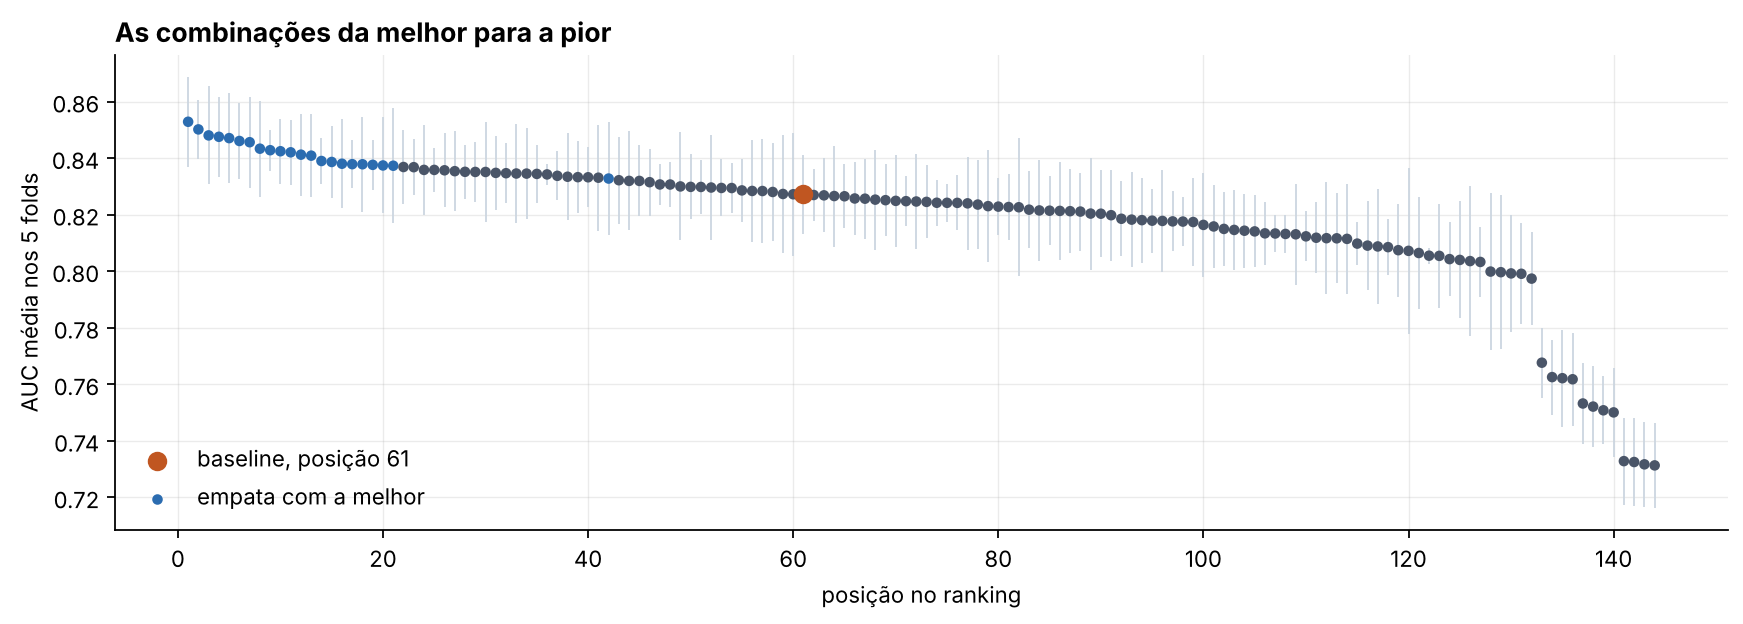

In [11]:
from IPython.display import Image, display

# as figuras saem do mesmo modulo de analise e vao para reports/figuras/e2
FIGURAS = RAIZ / "reports" / "figuras" / "e2"
figuras = {c.stem: c for c in analise.figuras(gravado, FIGURAS)}
display(Image(figuras["fig-al-ranking"]))

O efeito de uma etapa é lido de dois jeitos. A média por opção é o que o enunciado pede, mas
mistura contextos. A leitura pareada fixa as outras quatro etapas, compara a opção com a de
referência dentro de cada contexto e conta vitórias, empates e derrotas pela regra de empate.

In [12]:
for etapa in espaco.ETAPAS:
    print("###", etapa)
    print(analise.efeito_por_etapa(gravado, etapa).round(4).to_string(index=False), "\n")

### ausentes
   etapa              opcao  referencia  media  combinacoes  vitorias  empates  derrotas  ganho_medio
ausentes mediana_indicadora       False 0.8180           72       0.0     68.0       4.0      -0.0016
ausentes       mediana_moda        True 0.8195           72       NaN      NaN       NaN          NaN 

### encoding
   etapa  opcao  referencia  media  combinacoes  vitorias  empates  derrotas  ganho_medio
encoding   alvo       False 0.8225           72      13.0     59.0       0.0       0.0074
encoding onehot        True 0.8151           72       NaN      NaN       NaN          NaN 

### normalizacao
       etapa   opcao  referencia  media  combinacoes  vitorias  empates  derrotas  ganho_medio
normalizacao  minmax       False 0.8266           36      23.0     13.0       0.0       0.0364
normalizacao  padrao       False 0.8307           36      22.0     14.0       0.0       0.0405
normalizacao robusto       False 0.8277           36      23.0     13.0       0.0       0.03

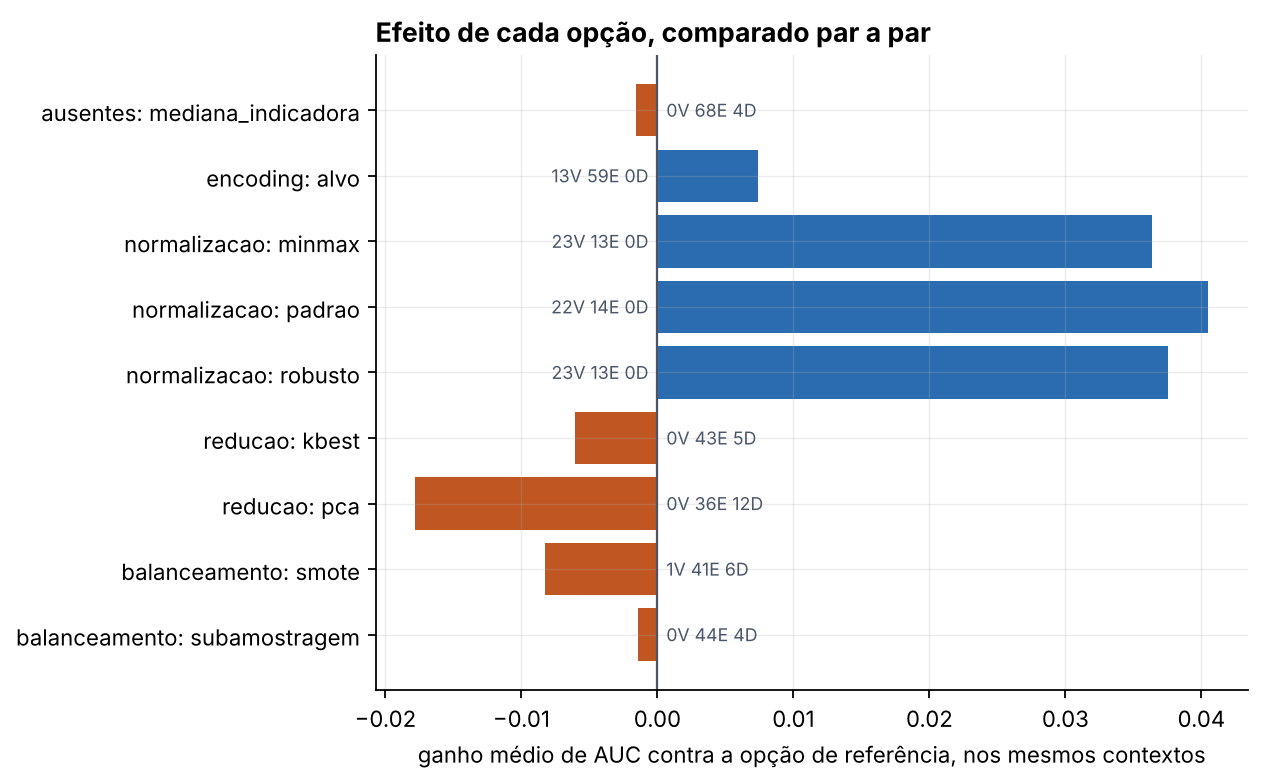

In [13]:
display(Image(figuras["fig-al-efeitos"]))

O balanceamento não aparece na AUC, que não depende de ponto de corte. Ele aparece nas métricas
da decisão final, tomada no corte de quatro votos em sete.

In [14]:
for metrica in ("recall", "precision", "f1", "roc_auc"):
    d = analise.efeito_por_etapa(gravado, "balanceamento", metrica)
    print("###", metrica)
    print(d.round(4).to_string(index=False), "\n")

### recall
        etapa         opcao  referencia  media  combinacoes  vitorias  empates  derrotas  ganho_medio
balanceamento           sem        True 0.5475           48       NaN      NaN       NaN          NaN
balanceamento         smote       False 0.7357           48      48.0      0.0       0.0       0.1883
balanceamento subamostragem       False 0.7410           48      48.0      0.0       0.0       0.1936 

### precision
        etapa         opcao  referencia  media  combinacoes  vitorias  empates  derrotas  ganho_medio
balanceamento           sem        True 0.6923           48       NaN      NaN       NaN          NaN
balanceamento         smote       False 0.5299           48       0.0      0.0      48.0      -0.1624
balanceamento subamostragem       False 0.5427           48       0.0      0.0      48.0      -0.1497 

### f1
        etapa         opcao  referencia  media  combinacoes  vitorias  empates  derrotas  ganho_medio
balanceamento           sem        True 0.6093

A regra de empate é o critério do enunciado e é por ela que o relatório decide. Como verificação
independente, aplicamos o teste de Wilcoxon pareado sobre as diferenças por fold, o que é possível
porque os folds são idênticos em todas as combinações: cada par compara a opção com a de
referência no mesmo contexto das outras quatro etapas e no mesmo fold.

In [15]:
from scipy.stats import wilcoxon

fold_a_fold = pd.read_csv(RESULTADOS / "resultados_por_fold.csv").merge(
    gravado[["id"] + espaco.ETAPAS], on="id")


def pareado(etapa, opcao, metrica, recorte=None):
    """Wilcoxon da opcao contra a referencia do baseline, par a par por contexto e fold."""
    contexto = [e for e in espaco.ETAPAS if e != etapa] + ["fold"]
    base = fold_a_fold if recorte is None else fold_a_fold.query(recorte)
    com = base[base[etapa] == opcao].set_index(contexto)[metrica]
    sem = base[base[etapa] == espaco.BASELINE[etapa]].set_index(contexto)[metrica]
    par = com.to_frame("com").join(sem.rename("sem"), how="inner").dropna()
    return len(par), (par["com"] - par["sem"]).mean(), wilcoxon(par["com"], par["sem"]).pvalue


print("afirmacao                                          n   diferenca         p")
for opcao in ("padrao", "minmax", "robusto"):
    n, dif, p = pareado("normalizacao", opcao, "roc_auc")
    print("%-14s contra nao normalizar, AUC  %5d   %+.4f   %9.2e" % (opcao, n, dif, p))

for metrica in ("recall", "precision", "roc_auc"):
    n, dif, p = pareado("balanceamento", "subamostragem", metrica)
    print("subamostragem em %-11s          %5d   %+.4f   %9.2e" % (metrica, n, dif, p))

print()
for recorte, rotulo in (("normalizacao == 'sem'", "sem normalizacao"),
                        ("normalizacao != 'sem'", "com normalizacao")):
    n, dif, p = pareado("reducao", "pca", "roc_auc", recorte)
    print("PCA contra nao reduzir, %-17s %5d   %+.4f   %9.2e" % (rotulo, n, dif, p))

afirmacao                                          n   diferenca         p
padrao         contra nao normalizar, AUC    180   +0.0405    2.94e-28
minmax         contra nao normalizar, AUC    180   +0.0364    9.97e-25


robusto        contra nao normalizar, AUC    180   +0.0375    7.35e-27
subamostragem em recall                 240   +0.1936    3.94e-41
subamostragem em precision              240   -0.1497    4.02e-41
subamostragem em roc_auc                240   -0.0014    2.55e-01

PCA contra nao reduzir, sem normalizacao     60   -0.0650    1.63e-11
PCA contra nao reduzir, com normalizacao    180   -0.0021    3.11e-03


Interação, na definição do enunciado, é a técnica que só se mostra benéfica na presença de
outra. A coluna `interacao` marca onde o veredito muda conforme a opção da outra etapa.

O balanceamento aparece também no F1, porque é nele que a decisão muda.

In [16]:
for a, b, m in (("reducao", "normalizacao", "roc_auc"), ("normalizacao", "encoding", "roc_auc"),
                ("balanceamento", "normalizacao", "roc_auc"), ("balanceamento", "normalizacao", "f1"),
                ("balanceamento", "encoding", "f1")):
    print("###", a, "por", b, "em", m)
    print(analise.interacoes(gravado, a, b, m).round(4).to_string(index=False), "\n")

### reducao por normalizacao em roc_auc
etapa_a opcao_a      etapa_b opcao_b  vitorias  empates  derrotas  ganho_medio veredito  interacao
reducao   kbest normalizacao  minmax         0       12         0       0.0002   empata      False
reducao     pca normalizacao  minmax         0       12         0      -0.0031   empata       True
reducao   kbest normalizacao  padrao         0       11         1      -0.0090   empata      False
reducao     pca normalizacao  padrao         0       12         0       0.0003   empata       True
reducao   kbest normalizacao robusto         0       11         1      -0.0088   empata      False
reducao     pca normalizacao robusto         0       12         0      -0.0034   empata       True
reducao   kbest normalizacao     sem         0        9         3      -0.0067   empata      False
reducao     pca normalizacao     sem         0        0        12      -0.0650    perde       True 

### normalizacao por encoding em roc_auc


     etapa_a opcao_a  etapa_b opcao_b  vitorias  empates  derrotas  ganho_medio veredito  interacao
normalizacao  minmax encoding    alvo        17        1         0       0.0487    vence       True
normalizacao  padrao encoding    alvo        15        3         0       0.0465    vence       True
normalizacao robusto encoding    alvo        15        3         0       0.0424    vence       True
normalizacao  minmax encoding  onehot         6       12         0       0.0241   empata       True
normalizacao  padrao encoding  onehot         7       11         0       0.0345   empata       True
normalizacao robusto encoding  onehot         8       10         0       0.0327   empata       True 

### balanceamento por normalizacao em roc_auc


      etapa_a       opcao_a      etapa_b opcao_b  vitorias  empates  derrotas  ganho_medio veredito  interacao
balanceamento         smote normalizacao  minmax         0       11         1      -0.0113   empata      False
balanceamento subamostragem normalizacao  minmax         0       12         0      -0.0017   empata      False
balanceamento         smote normalizacao  padrao         0       10         2      -0.0098   empata      False
balanceamento subamostragem normalizacao  padrao         0       12         0       0.0072   empata      False
balanceamento         smote normalizacao robusto         0        9         3      -0.0128   empata      False
balanceamento subamostragem normalizacao robusto         0       12         0       0.0019   empata      False
balanceamento         smote normalizacao     sem         1       11         0       0.0007   empata      False
balanceamento subamostragem normalizacao     sem         0        8         4      -0.0130   empata      False 


      etapa_a       opcao_a      etapa_b opcao_b  vitorias  empates  derrotas  ganho_medio veredito  interacao
balanceamento         smote normalizacao  minmax         0       10         2      -0.0102   empata       True
balanceamento subamostragem normalizacao  minmax         3        9         0       0.0024   empata       True
balanceamento         smote normalizacao  padrao         0        7         5      -0.0182   empata       True
balanceamento subamostragem normalizacao  padrao         2       10         0       0.0066   empata       True
balanceamento         smote normalizacao robusto         0       12         0      -0.0041   empata       True
balanceamento subamostragem normalizacao robusto         2       10         0       0.0137   empata       True
balanceamento         smote normalizacao     sem         9        3         0       0.0553    vence       True
balanceamento subamostragem normalizacao     sem         8        4         0       0.0409    vence       True 


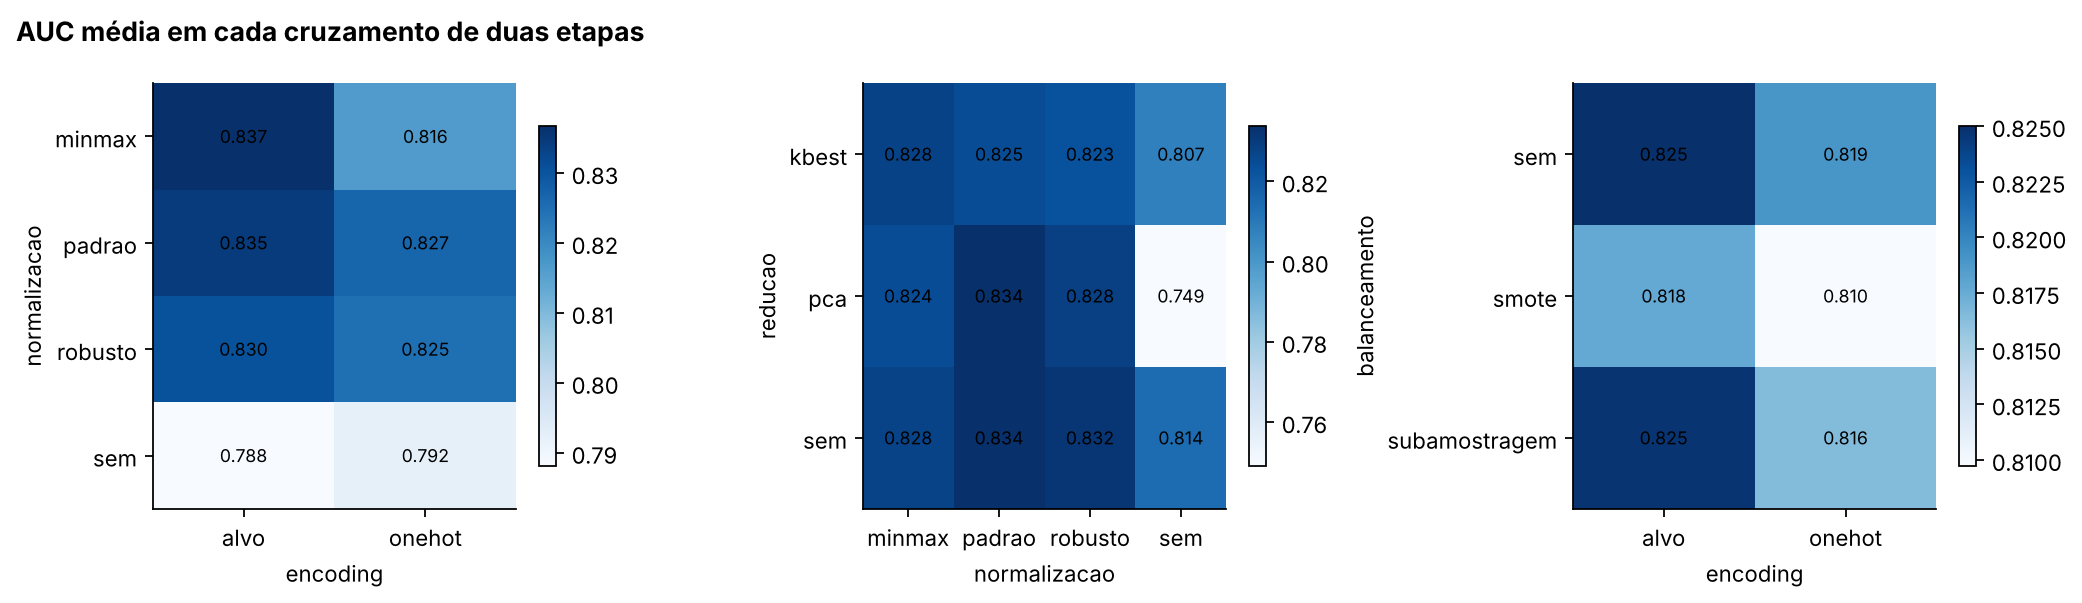

In [17]:
display(Image(figuras["fig-al-interacoes"]))

O PCA sem normalização é o caso mais claro, e a causa está na dimensão que chega ao
classificador.

In [18]:
pca = gravado[gravado["reducao"] == "pca"]
print(pca.groupby("normalizacao")[["roc_auc_media", "n_atributos"]].mean().round(3).to_string())
print("\nas doze piores da grade:")
piores = gravado.nsmallest(12, "roc_auc_media")
print("todas com PCA e sem normalizacao:",
      ((piores["reducao"] == "pca") & (piores["normalizacao"] == "sem")).all())
print(piores[["codigo", "roc_auc_media", "n_atributos"]]
      .round(3).to_string(index=False))

              roc_auc_media  n_atributos
normalizacao                            
minmax                0.824        25.25
padrao                0.834        36.60
robusto               0.828        15.90
sem                   0.749         2.00

as doze piores da grade:
todas com PCA e sem normalizacao: True
                                         codigo  roc_auc_media  n_atributos
mediana_indicadora|onehot|sem|pca|subamostragem          0.731          2.0
      mediana_moda|onehot|sem|pca|subamostragem          0.732          2.0
  mediana_indicadora|alvo|sem|pca|subamostragem          0.732          2.0
        mediana_moda|alvo|sem|pca|subamostragem          0.733          2.0
          mediana_indicadora|onehot|sem|pca|sem          0.750          2.0
                mediana_moda|onehot|sem|pca|sem          0.751          2.0
                  mediana_moda|alvo|sem|pca|sem          0.752          2.0
            mediana_indicadora|alvo|sem|pca|sem          0.753          2.0
     

## 5 · Custo

O tempo não acompanha a dimensão que chega ao classificador: a correlação é fraca e não
significativa. A explicação está na etapa mais cara da grade, que é também a que mais reduz,
porque estimar informação mútua em todas as colunas custa mais do que o kNN medir distância nelas.

In [19]:
from scipy.stats import spearmanr

por_opcao, mais_caras, correlacao = analise.custo(gravado)
print(por_opcao.round(3).to_string(index=False))
p = spearmanr(gravado["n_atributos"], gravado["tempo_total_s"]).pvalue
print("\nspearman entre tempo e colunas no kNN: %.3f, p = %.3f" % (correlacao, p))
print("tempo total: %.1f min | mediana: %.2f s"
      % (gravado["tempo_total_s"].sum() / 60, gravado["tempo_total_s"].median()))

# soma dos cinco folds, em segundos, por opcao de reducao
print(fold_a_fold.groupby("reducao")[["tempo_ajuste_s", "tempo_predicao_s"]].sum().round(1).to_string())
mais_caras.round(2)

        etapa              opcao  tempo_medio_s
     ausentes mediana_indicadora          1.689
     ausentes       mediana_moda          1.543
     encoding               alvo          1.022
     encoding             onehot          2.210
 normalizacao             minmax          1.676
 normalizacao             padrao          1.743
 normalizacao            robusto          1.720
 normalizacao                sem          1.326
      reducao              kbest          2.595
      reducao                pca          1.489
      reducao                sem          0.764
balanceamento                sem          1.599
balanceamento              smote          1.690
balanceamento      subamostragem          1.559

spearman entre tempo e colunas no kNN: -0.144, p = 0.086
tempo total: 3.9 min | mediana: 0.92 s
         tempo_ajuste_s  tempo_predicao_s
reducao                                  
kbest              93.4              31.2
pca                17.5              54.0
sem            

,id,codigo,n_atributos,tempo_total_s
98,99,mediana_indicadora|onehot|minmax|kbest|smote,10.0,3.99
87,88,mediana_indicadora|onehot|padrao|kbest|sem,10.0,3.92
107,108,mediana_indicadora|onehot|robusto|kbest|smote,10.0,3.91
105,106,mediana_indicadora|onehot|robusto|kbest|sem,10.0,3.91
89,90,mediana_indicadora|onehot|padrao|kbest|smote,10.0,3.90
88,89,mediana_indicadora|onehot|padrao|kbest|subamos...,10.0,3.89
80,81,mediana_indicadora|onehot|sem|kbest|smote,10.0,3.79
96,97,mediana_indicadora|onehot|minmax|kbest|sem,10.0,3.79
106,107,mediana_indicadora|onehot|robusto|kbest|subamo...,10.0,3.72
78,79,mediana_indicadora|onehot|sem|kbest|sem,10.0,3.68


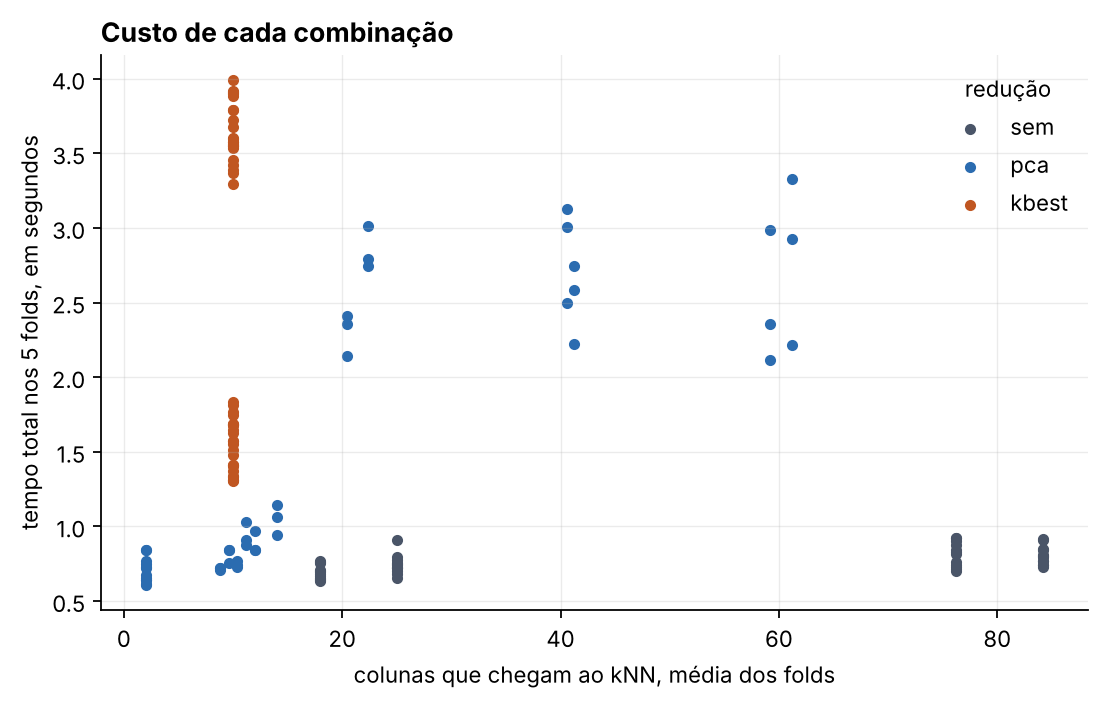

In [20]:
display(Image(figuras["fig-al-custo"]))

## 6 · Robustez

As três checagens são produzidas por `python src/robustez_e2.py` sobre doze combinações: o
baseline, as cinco melhores, as cinco piores e a melhor de cada opção de balanceamento. A mais
importante é a validação temporal, que treina até 2017 e testa de 2018 em diante.

In [21]:
temporal = pd.read_csv(RESULTADOS / "robustez_temporal.csv")
print(temporal[["codigo", "roc_auc_5fold", "roc_auc", "otimismo_5fold"]]
      .sort_values("otimismo_5fold").round(4).to_string(index=False))

genero = pd.read_csv(RESULTADOS / "robustez_genero.csv")
print("\npor genero, media das doze combinacoes:")
print(genero.groupby("genero")[["n", "prevalencia", "roc_auc", "recall"]].mean().round(3).to_string())

print("\nrevocacao em documentario, por combinacao:")
print(genero[genero["genero"] == "Documentário"].sort_values("recall")[["codigo", "roc_auc", "recall"]]
      .round(3).to_string(index=False))

limiar = pd.read_csv(RESULTADOS / "robustez_limiar.csv")
print("\nrevocacao media por corte do alvo e balanceamento, nas doze combinacoes:")
print(limiar.pivot_table(values="recall", index="balanceamento", columns="quantil").round(3).to_string())

print("\ncorrelacao entre os rankings de P50, P75 e P90:")
print(pd.read_csv(RESULTADOS / "robustez_limiar_spearman.csv").round(4).to_string(index=False))

                                          codigo  roc_auc_5fold  roc_auc  otimismo_5fold
mediana_indicadora|alvo|padrao|pca|subamostragem         0.8471   0.7986          0.0485
      mediana_moda|alvo|padrao|sem|subamostragem         0.8480   0.7903          0.0577
      mediana_moda|alvo|padrao|pca|subamostragem         0.8528   0.7929          0.0599
                mediana_moda|alvo|minmax|sem|sem         0.8475   0.7493          0.0982
              mediana_moda|alvo|minmax|pca|smote         0.8424   0.7387          0.1037
                mediana_moda|alvo|minmax|pca|sem         0.8501   0.7376          0.1126
       mediana_moda|onehot|sem|pca|subamostragem         0.7317   0.5559          0.1758
   mediana_indicadora|alvo|sem|pca|subamostragem         0.7325   0.5564          0.1761
 mediana_indicadora|onehot|sem|pca|subamostragem         0.7313   0.5550          0.1763
         mediana_moda|alvo|sem|pca|subamostragem         0.7328   0.5562          0.1766
           mediana_in

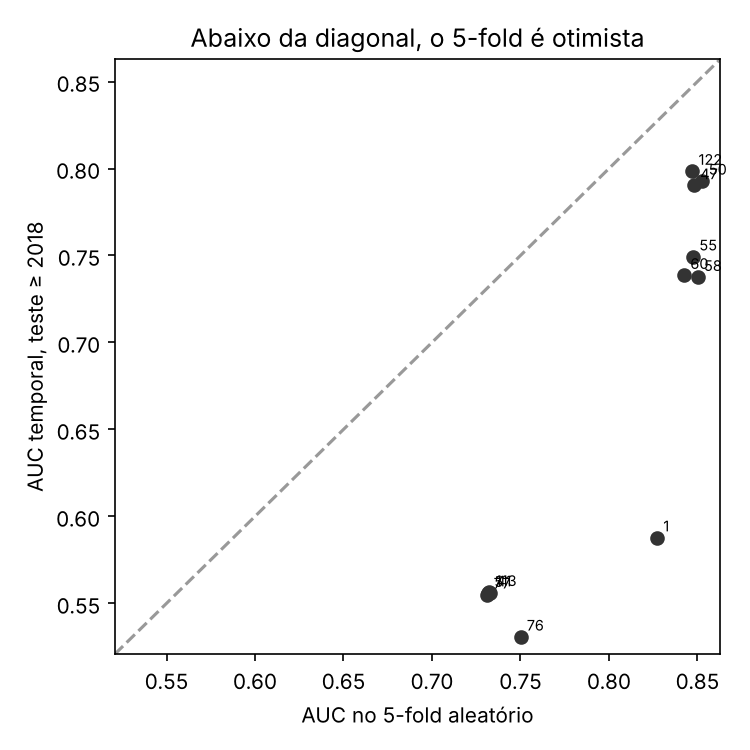

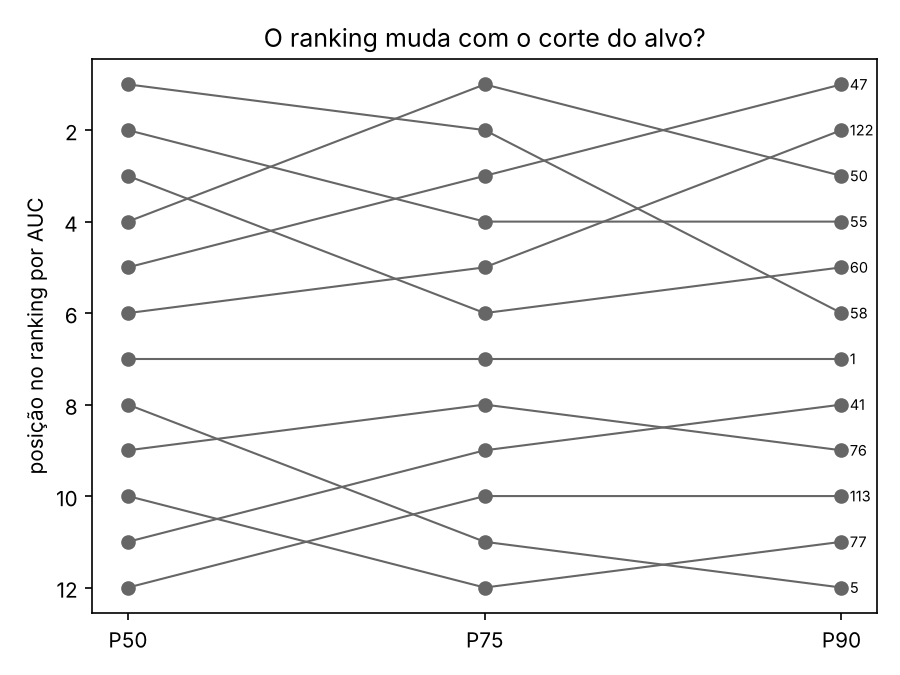

In [22]:
for nome in ("fig-lf-auc-5fold-temporal", "fig-lf-ranking-limiar"):
    display(Image(FIGURAS / (nome + ".png")))

## 7 · O que a grade mostrou

A discussão completa está na seção 5 do relatório. Em resumo:

1. A normalização é a única etapa que decide o resultado, com 68 vitórias e nenhuma derrota em
   108 comparações pareadas. As três escalas empatam entre si.
2. A redução nunca ganhou. A seleção de dez colunas empata com a matriz completa em 43 de 48
   contextos, o que barateia o modelo sem custar AUC.
3. O PCA sem normalização é o erro de construção da grade: sobram dois componentes, dominados
   pelo ano e pelas contagens, e a AUC cai 0,065.
4. O balanceamento não move a AUC e muda a decisão: a revocação sobe cerca de 0,19 em todos os
   48 contextos, a precisão cai 0,15.
5. O baseline empata com 104 das outras 143 combinações em cinco folds, mas é o que menos
   sobrevive à validação temporal, caindo de 0,827 para 0,588. Seis combinações que empatam com a
   melhor em cinco folds ficam entre 0,738 e 0,799 no futuro.